# EEG Seizure Detection: Baseline Models

Notebook compatto per caricare i dati, allenare i baseline classici e fare hypertuning usando direttamente i metodi delle classi modello.


## 1. Setup

In [11]:
import os
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())
sys.path.insert(0, str(proj_dir))

from utils.models.model_classes import (
    LogisticRegressionModel,
    NaiveBayesModel,
    SVMModel,
    RandomForestModel,
    KNNModel,
    XGBModel,
    LGBModel,
)

print("Imports successful")

RANDOM_STATE = 42
N_JOBS = -1


Imports successful


## 2. Data

In [12]:
SELECTED_SUBJ = "chb04"
SPLIT_PATH = proj_dir / "data" / "split" / "task_1" 
SUBJ_PATH = SPLIT_PATH / SELECTED_SUBJ
SELECTED_FILES = sorted([f.stem for f in SUBJ_PATH.glob("*.npz")]) # ["chb04_08", "chb04_05", "chb04_01", "chb04_02"]
CHANNEL_INDEX = 3
BALANCE_TRAIN = False


def class_counts(y):
    return np.bincount(np.asarray(y).astype(int), minlength=2)


def selected_feature_indices(feature_names, channel_name):
    return [i for i, name in enumerate(feature_names) if str(name).startswith(f"{channel_name}_")]


def make_frame(X, y, feature_names):
    df = pd.DataFrame(X, columns=feature_names)
    df["is_seizure"] = np.asarray(y).astype(int)
    return df


def load_file(file_name, channel_index=CHANNEL_INDEX):
    patient = file_name.split("_")[0]
    data = np.load(SPLIT_PATH / patient / f"{file_name}.npz", allow_pickle=True)
    channel_name = str(data["channels"][channel_index])
    idx = selected_feature_indices(data["feature_names"], channel_name)
    names = data["feature_names"][idx]
    frames = {
        split: make_frame(data[f"X_{split}"][:, idx], data[f"y_{split}"], names)
        for split in ["train", "val", "test"]
    }
    print(f"Loaded {file_name} | channel {channel_index}: {channel_name} | features: {len(idx)}")
    return frames


loaded = [load_file(file_name) for file_name in SELECTED_FILES]
split_frames = {
    split: pd.concat([frames[split] for frames in loaded], ignore_index=True)
    for split in ["train", "val", "test"]
}

if BALANCE_TRAIN:
    pos = split_frames["train"][split_frames["train"]["is_seizure"] == 1]
    neg = split_frames["train"][split_frames["train"]["is_seizure"] == 0].sample(len(pos), random_state=RANDOM_STATE)
    split_frames["train"] = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE)

for split, df in split_frames.items():
    counts = class_counts(df["is_seizure"])
    print(f"{split:5s}: {df.shape} | class distribution: {counts}")
    if np.count_nonzero(counts) < 2:
        print(f"WARNING: {split} contains only one class; ROC-AUC and seizure metrics are not reliable.")


Loaded chb04_01 | channel 3: P7-O1 | features: 18
Loaded chb04_02 | channel 3: P7-O1 | features: 18
Loaded chb04_05 | channel 3: P7-O1 | features: 18
Loaded chb04_08 | channel 3: P7-O1 | features: 18
Loaded chb04_28 | channel 3: P7-O1 | features: 18
train: (11005, 19) | class distribution: [10867   138]
val  : (3498, 19) | class distribution: [3476   22]
test : (4034, 19) | class distribution: [4034    0]


## 3. Helpers

In [13]:
def compute_class_weights(y):
    counts = class_counts(y)
    total = counts.sum()
    return {cls: total / (len(counts) * count) for cls, count in enumerate(counts) if count > 0}


def compute_scale_pos_weight(y):
    counts = class_counts(y)
    return counts[0] / counts[1] if counts[1] > 0 else 1


def positive_scores(model, X):
    if not hasattr(model, "predict_proba"):
        return None
    scores = model.predict_proba(X)
    if getattr(scores, "ndim", 1) == 2:
        return scores[:, 1] if scores.shape[1] > 1 else None
    return scores


def metrics_for(model, df):
    X, y = model.preprocess(df, is_training=False, verbose=True)
    pred = model.predict(X)
    scores = positive_scores(model, X)
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, average="weighted", zero_division=0),
        "recall": recall_score(y, pred, average="weighted", zero_division=0),
        "f1": f1_score(y, pred, average="weighted", zero_division=0),
        "precision_seizure": precision_score(y, pred, pos_label=1, zero_division=0),
        "recall_seizure": recall_score(y, pred, pos_label=1, zero_division=0),
        "f1_seizure": f1_score(y, pred, pos_label=1, zero_division=0),
        "roc_auc": np.nan,
    }
    if scores is not None and len(np.unique(y)) == 2:
        metrics["roc_auc"] = roc_auc_score(y, scores)
    return metrics


def fit_and_score(name, model, results, models):
    X_train, y_train = model.preprocess(split_frames["train"], is_training=True, verbose=True)
    model.train(X_train, y_train)
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row.update({f"train_{k}": v for k, v in metrics_for(model, split_frames["train"]).items()})
    results[name] = row
    models[name] = model
    print(f"{name:20s} | val_f1={row['val_f1']:.4f} | test_f1={row['f1']:.4f} | seizure_recall={row['recall_seizure']:.4f}")


## 4. Train Baselines

In [14]:
class_weights = compute_class_weights(split_frames["train"]["is_seizure"])
scale_pos_weight = compute_scale_pos_weight(split_frames["train"]["is_seizure"])

models = {
    "LogisticRegression": LogisticRegressionModel(class_weight=class_weights, n_jobs=N_JOBS, scaler=None),
    "NaiveBayes": NaiveBayesModel(scaler=None),
    "SVM": SVMModel(class_weight=class_weights, scaler=None),
    "KNN": KNNModel(n_jobs=N_JOBS, scaler=None),
    "RandomForest": RandomForestModel(class_weight=class_weights, n_estimators=200, n_jobs=N_JOBS, scaler=None),
    "XGBoost": XGBModel(
        eval_metric="logloss",
        scaler=None,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        n_jobs=N_JOBS,
    ),
    "LightGBM": LGBModel(class_weight=class_weights, n_estimators=200, verbose=-1, n_jobs=N_JOBS, scaler=None),
}

results = {}
trained_models = {}
for name, model in models.items():
    fit_and_score(name, model, results, trained_models)

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
results_df


[LogisticRegression] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
is_seizure
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[LogisticRegression] Analyzing multicollinearity (threshold=0.95)...
[LogisticRegression] Dropped 3 redundant features. Remaining: 15
[LogisticRegression] Starting training...
[LogisticRegression] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
is_seizure
0    1.0
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 15 features.
[LogisticRegression] Features shape: (3498, 18), Labels shape: (3498,)
Label distribution:
is_seizure
0    0.993711
1    0.006289
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 15 features.
[LogisticRegression] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
is_seizure
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 15 features.
LogisticRegression   | 

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,val_f1_seizure,val_roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc
KNN,0.998265,1.0,0.998265,0.999132,0.0,0.0,0.0,NaN,0.993711,0.987461,...,0.000000,0.491657,0.993458,0.992991,0.993458,0.992633,0.902439,0.536232,0.672727,0.996422
RandomForest,0.999752,1.0,0.999752,0.999876,0.0,0.0,0.0,NaN,0.993711,0.987461,...,0.000000,0.590072,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LightGBM,0.998265,1.0,0.998265,0.999132,0.0,0.0,0.0,NaN,0.993425,0.987459,...,0.000000,0.684734,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
XGBoost,0.993803,1.0,0.993803,0.996892,0.0,0.0,0.0,NaN,0.989994,0.987438,...,0.000000,0.584645,0.999091,0.999153,0.999091,0.999107,0.932432,1.000000,0.965035,1.000000
NaiveBayes,0.971492,1.0,0.971492,0.985540,0.0,0.0,0.0,NaN,0.980274,0.987789,...,0.028169,0.868396,0.974557,0.984424,0.974557,0.978872,0.250000,0.514493,0.336493,0.934854
SVM,0.868617,1.0,0.868617,0.929690,0.0,0.0,0.0,NaN,0.947113,0.987155,...,0.000000,0.193025,0.950750,0.986684,0.950750,0.965829,0.173139,0.775362,0.283069,0.935425
LogisticRegression,0.921666,1.0,0.921666,0.959236,0.0,0.0,0.0,NaN,0.933962,0.988375,...,0.033473,0.601593,0.935666,0.988433,0.935666,0.957572,0.154964,0.927536,0.265560,0.974655


## 5. Hypertune Top 3

Top 3 by validation F1: ['KNN', 'RandomForest', 'LightGBM']
Hypertuning KNN...
[KNN] Grid Search...

Starting tuning on 14503 samples...

Best parameters found for KNeighborsClassifier:
{'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
[KNN] Train model with best params...
[KNN] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
is_seizure
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[KNN] Analyzing multicollinearity (threshold=0.95)...
[KNN] Dropped 3 redundant features. Remaining: 15
[KNN] Starting training...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10867
           1       1.00      1.00      1.00       138

    accuracy                           1.00     11005
   macro avg       1.00      1.00      1.00     11005
weighted avg       1.00      1.00      1.00     11005



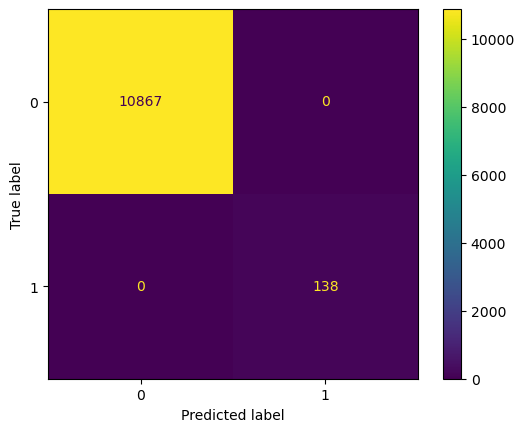

[KNN] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
is_seizure
0    1.0
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.
[KNN] Features shape: (3498, 18), Labels shape: (3498,)
Label distribution:
is_seizure
0    0.993711
1    0.006289
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.
Hypertuning RandomForest...
[RandomForest] Grid Search...

Best parameters found for RandomForestClassifier:
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
[RandomForest] Train model with best params...
[RandomForest] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[RandomForest] Starting training...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10867
           1       0.78      1.00      0.88       138

    accuracy                           1.00     11005
   macro avg       0

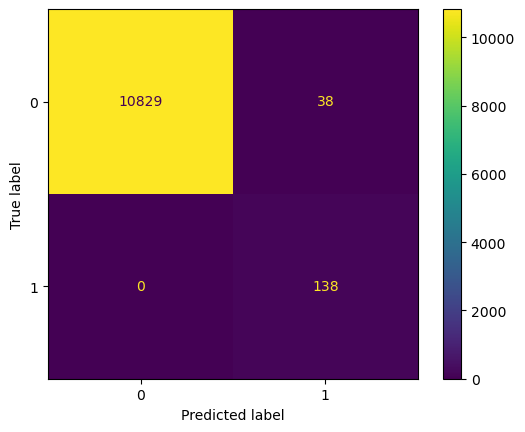

[RandomForest] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
0    1.0
Name: proportion, dtype: float64
[RandomForest] Features shape: (3498, 18), Labels shape: (3498,)
Label distribution:
0    0.993711
1    0.006289
Name: proportion, dtype: float64
Hypertuning LightGBM...
[LGBM] Starting Randomized Search...

Best parameters found for LGBMClassifier:
{'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best params: {'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best validation score: 1.0000
[LGBM] Train model with best params...
[LGBM] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
is_seizure
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[LGBM] Starting training...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10867
           1       1.00      1.00      1.00       138

    accuracy        

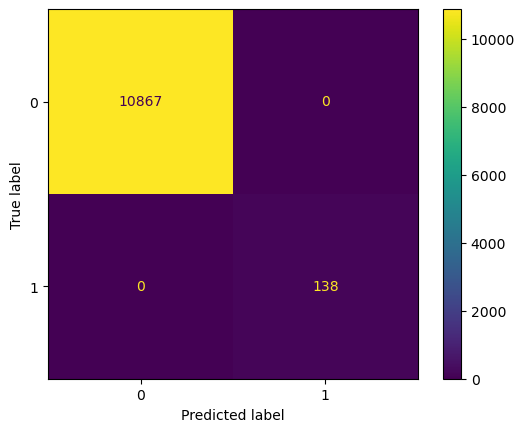

[LGBM] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
is_seizure
0    1.0
Name: proportion, dtype: float64
[LGBM] Features shape: (3498, 18), Labels shape: (3498,)
Label distribution:
is_seizure
0    0.993711
1    0.006289
Name: proportion, dtype: float64


,best_params,search_val_f1,val_f1,f1,f1_seizure,roc_auc
KNN_tuned,"{'weights': 'distance', 'n_neighbors': 11, 'me...",0.990576,0.990576,0.999628,0.0,NaN
RandomForest_tuned,"{'min_samples_split': 2, 'min_samples_leaf': 1...",1.0,0.987996,0.99851,0.0,NaN
LightGBM_tuned,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0,0.990433,0.999256,0.0,NaN


In [15]:
param_grids = {
    "LogisticRegression": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs", "liblinear"]},
    "NaiveBayes": {"var_smoothing": np.logspace(-12, -6, 7)},
    "SVM": {"C": [0.1, 1.0, 10.0], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7, 11, 15], "weights": ["uniform", "distance"], "metric": ["minkowski", "manhattan"]},
    "RandomForest": {"max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    "XGBoost": {"max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
    "LightGBM": {"max_depth": [-1, 5, 10, 20], "learning_rate": [0.01, 0.05, 0.1], "num_leaves": [15, 31, 63], "min_child_samples": [10, 20, 50]},
}

top3 = [name for name in results_df.index if name in param_grids][:3]
tuning_rows = {}
print(f"Top 3 by validation F1: {top3}")

for name in top3:
    print(f"Hypertuning {name}...")
    model = trained_models[name]
    search = model.hypertune_pipeline(
        split_frames["train"],
        split_frames["val"],
        param_grids[name],
        n_iter=12,
        scoring="f1_weighted",
        verbose=False,
    )
    tuned_name = f"{name}_tuned"
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row["best_params"] = search.best_params_
    row["search_val_f1"] = search.best_score_
    results[tuned_name] = row
    trained_models[tuned_name] = model
    tuning_rows[tuned_name] = row

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
pd.DataFrame(tuning_rows).T[["best_params", "search_val_f1", "val_f1", "f1", "f1_seizure", "roc_auc"]]


## 6. Results

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc,best_params,search_val_f1
KNN,0.998265,1.0,0.998265,0.999132,0.0,0.0,0.0,NaN,0.993711,0.987461,...,0.993458,0.992991,0.993458,0.992633,0.902439,0.536232,0.672727,0.996422,NaN,NaN
RandomForest,0.999752,1.0,0.999752,0.999876,0.0,0.0,0.0,NaN,0.993711,0.987461,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
KNN_tuned,0.999256,1.0,0.999256,0.999628,0.0,0.0,0.0,NaN,0.993711,0.987461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'weights': 'distance', 'n_neighbors': 11, 'me...",0.990576
LightGBM,0.998265,1.0,0.998265,0.999132,0.0,0.0,0.0,NaN,0.993425,0.987459,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
LightGBM_tuned,0.998513,1.0,0.998513,0.999256,0.0,0.0,0.0,NaN,0.993425,0.987459,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0
XGBoost,0.993803,1.0,0.993803,0.996892,0.0,0.0,0.0,NaN,0.989994,0.987438,...,0.999091,0.999153,0.999091,0.999107,0.932432,1.0,0.965035,1.0,NaN,NaN
RandomForest_tuned,0.997025,1.0,0.997025,0.99851,0.0,0.0,0.0,NaN,0.988565,0.987429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'min_samples_split': 2, 'min_samples_leaf': 1...",1.0
NaiveBayes,0.971492,1.0,0.971492,0.98554,0.0,0.0,0.0,NaN,0.980274,0.987789,...,0.974557,0.984424,0.974557,0.978872,0.25,0.514493,0.336493,0.934854,NaN,NaN
SVM,0.868617,1.0,0.868617,0.92969,0.0,0.0,0.0,NaN,0.947113,0.987155,...,0.95075,0.986684,0.95075,0.965829,0.173139,0.775362,0.283069,0.935425,NaN,NaN
LogisticRegression,0.921666,1.0,0.921666,0.959236,0.0,0.0,0.0,NaN,0.933962,0.988375,...,0.935666,0.988433,0.935666,0.957572,0.154964,0.927536,0.26556,0.974655,NaN,NaN


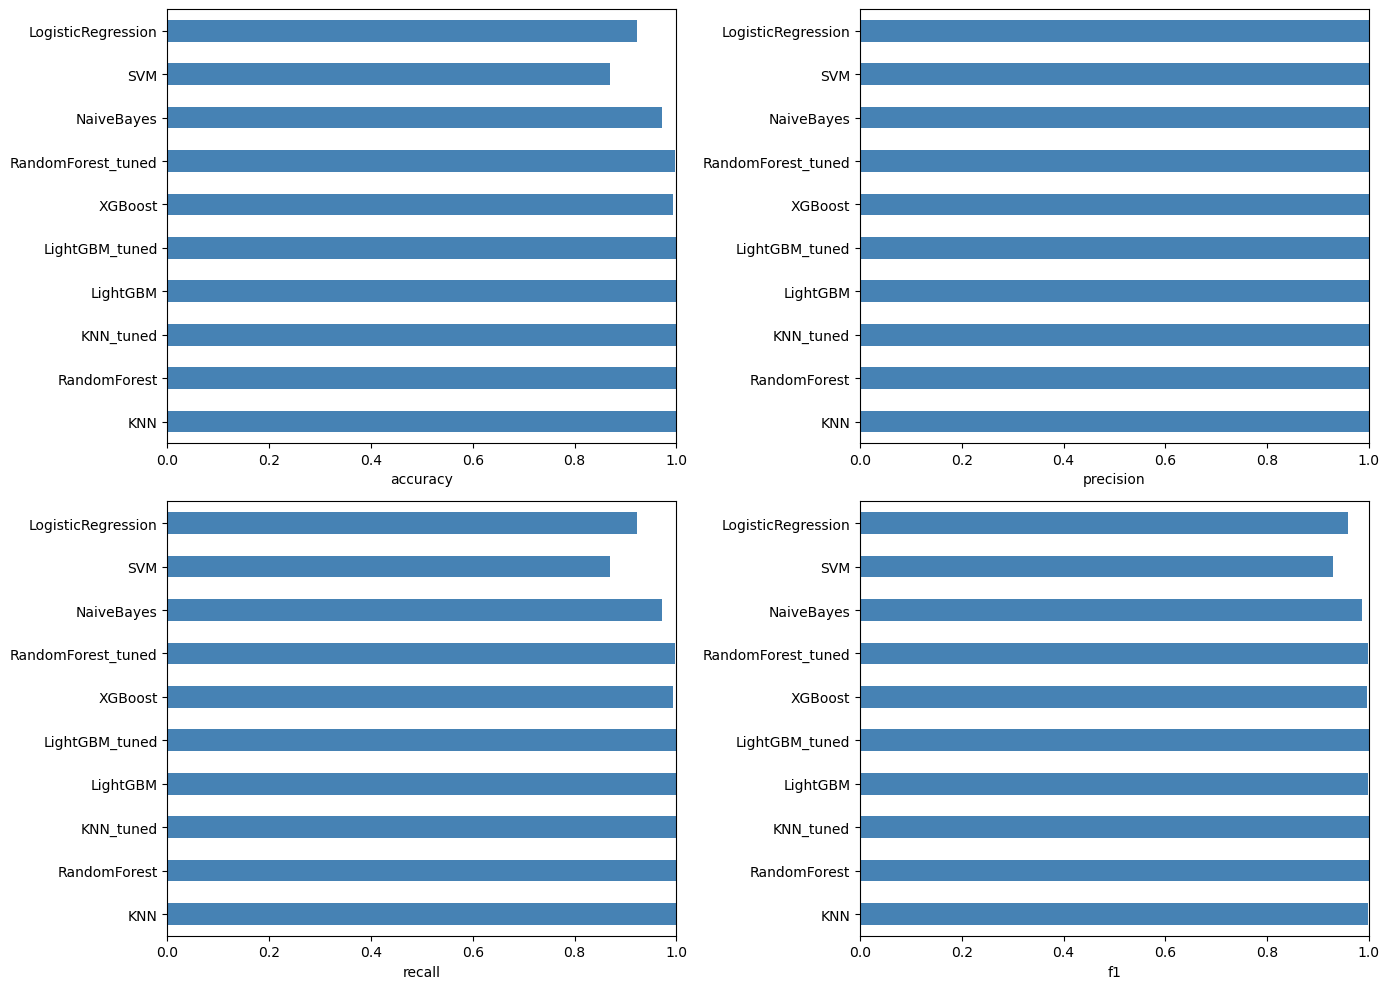

Best model by validation F1: KNN
accuracy                   0.998265
precision                       1.0
recall                     0.998265
f1                         0.999132
precision_seizure               0.0
recall_seizure                  0.0
f1_seizure                      0.0
roc_auc                         NaN
val_accuracy               0.993711
val_precision              0.987461
val_recall                 0.993711
val_f1                     0.990576
val_precision_seizure           0.0
val_recall_seizure              0.0
val_f1_seizure                  0.0
val_roc_auc                0.491657
train_accuracy             0.993458
train_precision            0.992991
train_recall               0.993458
train_f1                   0.992633
train_precision_seizure    0.902439
train_recall_seizure       0.536232
train_f1_seizure           0.672727
train_roc_auc              0.996422
best_params                     NaN
search_val_f1                   NaN
Name: KNN, dtype: object


In [16]:
display(results_df)

metrics = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for metric, ax in zip(metrics, axes.flatten()):
    results_df[metric].astype(float).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

best_model_name = results_df["val_f1"].idxmax()
print(f"Best model by validation F1: {best_model_name}")
print(results_df.loc[best_model_name])


## Prediction on Test split of the best model

Test metrics for KNN before tuning:
{'val_accuracy': 0.9937106918238994, 'val_precision': np.float64(0.9874609390451328), 'val_recall': np.float64(0.9937106918238994), 'val_f1': np.float64(0.9905759577802908), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.4916570771001151)}
Test metrics for KNN_tuned after tuning:
{'val_accuracy': 0.9937106918238994, 'val_precision': np.float64(0.9874609390451328), 'val_recall': np.float64(0.9937106918238994), 'val_f1': np.float64(0.9905759577802908), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.48647871116225544)}
--------------------------------------------------
[KNN] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
is_seizure
0    1.0
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.
              precision    

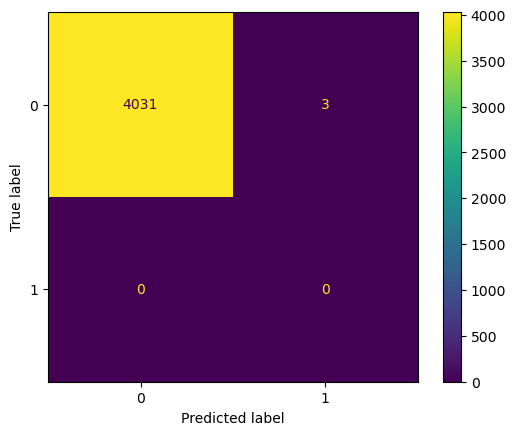

Test metrics for RandomForest before tuning:
{'val_accuracy': 0.9937106918238994, 'val_precision': np.float64(0.9874609390451328), 'val_recall': np.float64(0.9937106918238994), 'val_f1': np.float64(0.9905759577802908), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.5900721832827701)}
Test metrics for RandomForest_tuned after tuning:
{'val_accuracy': 0.9885648942252716, 'val_precision': np.float64(0.9874286127376564), 'val_recall': np.float64(0.9885648942252716), 'val_f1': np.float64(0.9879964267760333), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.5434930432053562)}
--------------------------------------------------
[RandomForest] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
0    1.0
Name: proportion, dtype: float64
              precision    recall  f1-score   support

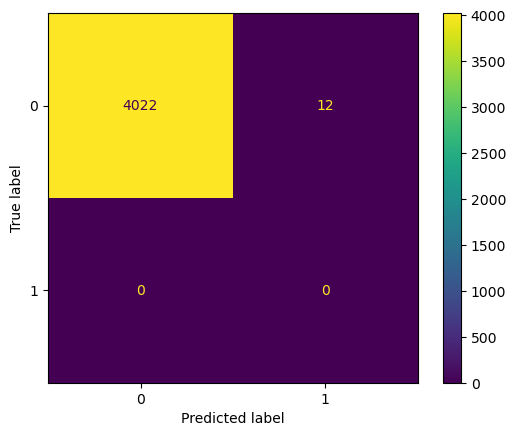

Test metrics for LightGBM before tuning:
{'val_accuracy': 0.9934248141795312, 'val_precision': np.float64(0.9874591518696169), 'val_recall': np.float64(0.9934248141795312), 'val_f1': np.float64(0.9904329998818444), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.6847342818286432)}
Test metrics for LightGBM_tuned after tuning:
{'val_accuracy': 0.9934248141795312, 'val_precision': np.float64(0.9874591518696169), 'val_recall': np.float64(0.9934248141795312), 'val_f1': np.float64(0.9904329998818444), 'val_precision_seizure': np.float64(0.0), 'val_recall_seizure': np.float64(0.0), 'val_f1_seizure': np.float64(0.0), 'val_roc_auc': np.float64(0.5059891202008577)}
--------------------------------------------------
[LGBM] Features shape: (4034, 18), Labels shape: (4034,)
Label distribution:
is_seizure
0    1.0
Name: proportion, dtype: float64
              precision    recall  f1-score   support

   

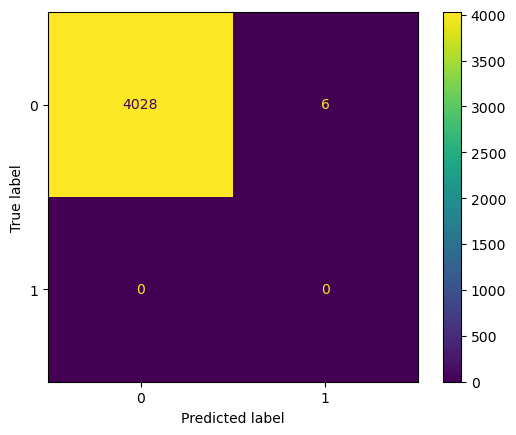

In [17]:
for name in top3:
    print(f"Test metrics for {name} before tuning:")
    print({k: v for k, v in results[name].items() if k.startswith("test_") or k.startswith("val_")})
    tuned_name = f"{name}_tuned"
    print(f"Test metrics for {tuned_name} after tuning:")
    print({k: v for k, v in results[tuned_name].items() if k.startswith("test_") or k.startswith("val_")})
    print("-" * 50)
    model = trained_models[tuned_name]
    model.test_pipeline(split_frames["test"], verbose=True)

[KNN] Grid Search...

Starting tuning on 14503 samples...
Fitting 1 folds for each of 12 candidates, totalling 12 fits

Best parameters found for KNeighborsClassifier:
{'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
[KNN] Train model with best params...
[KNN] Features shape: (11005, 18), Labels shape: (11005,)
Label distribution:
is_seizure
0    0.98746
1    0.01254
Name: proportion, dtype: float64
[KNN] Analyzing multicollinearity (threshold=0.95)...
[KNN] Dropped 3 redundant features. Remaining: 15
[KNN] Starting training...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10867
           1       1.00      1.00      1.00       138

    accuracy                           1.00     11005
   macro avg       1.00      1.00      1.00     11005
weighted avg       1.00      1.00      1.00     11005



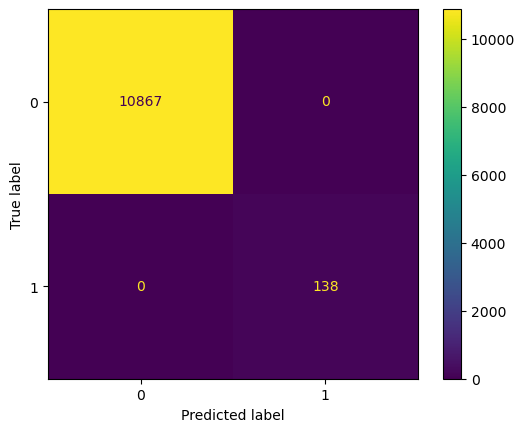

In [18]:
model = trained_models['KNN']
search = model.hypertune_pipeline(
            split_frames["train"],
            split_frames["val"],
            param_grids["KNN"],
            n_iter=12,
            scoring="f1_weighted",
            verbose=True,
            model_name='KNN',
        )
